# Extended kagome n=1 fluid mesh comparison

This notebook compares the coarse, normal, and fine COMSOL exports for extended kagome with $n=1$. At each $b$ value, the two eigenfrequencies are ordered by frequency and extracted. The upper band is plotted in the same normalized and mean-centered two-panel layout used in the final cell of `fig5_fluid_coarse.ipynb`.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

notebook_dir = next(
    candidate
    for candidate in (
        Path.cwd(),
        Path('processing/notebooks/testing_codes'),
        Path('processing/notebooks/paper_fig_upload'),
    )
    if (candidate / 'defs.py').is_file()
)
sys.path.insert(0, str(notebook_dir.resolve()))
# Reload the local helper when this notebook shares a live kernel.
sys.modules.pop('defs', None)
from defs import band_frequency_matrix, extract_band_structure

In [2]:
data_dir = next(
    path.resolve()
    for path in (Path('../../../data/simulation'), Path('data/simulation'))
    if path.is_dir()
)
out_dir = next(
    path.resolve()
    for path in (Path('../../../output/paper_upload'), Path('output/paper_upload'))
    if path.is_dir()
)

MESH_LEVELS = ('coarse', 'normal', 'fine')
SHOW_AXIS_TICKS_AND_LABELS = True
SAVE_PLOT = True

## Discover the three fluid mesh exports

In [3]:
filename_pattern = re.compile(
    r'^extkag_1_fluid_(coarse|normal|fine)_2bands\.csv$'
)
mesh_files = {}
for csv_path in data_dir.glob('extkag_1_fluid_*_2bands.csv'):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue
    mesh_level = match.group(1)
    if mesh_level in mesh_files:
        raise ValueError(f'Multiple CSV files found for {mesh_level} mesh')
    mesh_files[mesh_level] = csv_path

if set(mesh_files) != set(MESH_LEVELS):
    missing = set(MESH_LEVELS) - set(mesh_files)
    raise FileNotFoundError(
        'Missing fluid mesh exports: ' + ', '.join(sorted(missing))
    )

for mesh_level in MESH_LEVELS:
    print(f'{mesh_level}: {mesh_files[mesh_level].name}')

file_labels = {
    re.sub(
        r'_(coarse|normal|fine)_', '_',
        re.sub(r'^extkag_1_', '', csv_path.stem)
    )
    for csv_path in mesh_files.values()
}
if len(file_labels) != 1:
    raise ValueError(
        f'Expected one shared file label, found {sorted(file_labels)}'
    )
file_label = next(iter(file_labels))


coarse: extkag_1_fluid_coarse_2bands.csv
normal: extkag_1_fluid_normal_2bands.csv
fine: extkag_1_fluid_fine_2bands.csv


## Extract both bands

In [4]:
band_data = {}
for mesh_level in MESH_LEVELS:
    dataset = extract_band_structure(
        mesh_files[mesh_level], max_bands=2, band_selection='top'
    )
    bands_hz = band_frequency_matrix(dataset)
    if bands_hz.shape[1] != 2:
        raise ValueError(
            f'{mesh_level} mesh contains {bands_hz.shape[1]} selected bands; expected 2'
        )
    if not np.all(np.diff(bands_hz, axis=1) >= 0):
        raise ValueError(f'{mesh_level} bands are not frequency ordered')
    band_data[mesh_level] = dataset
    print(f'{mesh_level}: extracted 2 bands at {bands_hz.shape[0]} b values')

coarse: extracted 2 bands at 48 b values
normal: extracted 2 bands at 48 b values
fine: extracted 2 bands at 48 b values


## Compare the flat bands across mesh levels

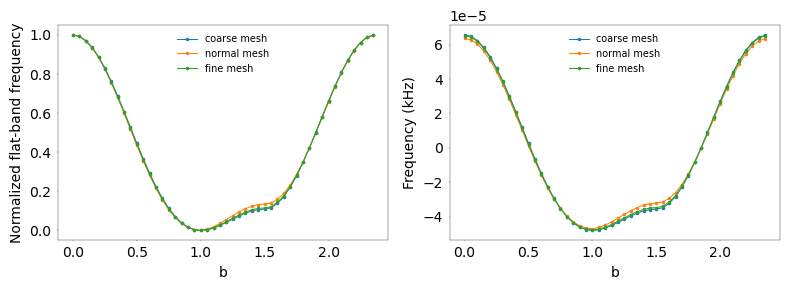

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

for mesh_level, dataset in band_data.items():
    b_values = np.asarray(list(dataset['frequencies_by_b_hz']))
    flat_band_hz = band_frequency_matrix(dataset)[:, -1]
    minimum_hz = flat_band_hz.min()
    maximum_hz = flat_band_hz.max()
    bandwidth_hz = maximum_hz - minimum_hz
    normalized_flat_band = (
        (flat_band_hz - minimum_hz) / bandwidth_hz
        if bandwidth_hz > 0
        else np.zeros_like(flat_band_hz)
    )
    label = f'{mesh_level} mesh'
    axes[0].plot(
        b_values, normalized_flat_band, marker='.', linewidth=0.75,
        markersize=3, label=label
    )
    axes[1].plot(
        b_values, (flat_band_hz - np.average(flat_band_hz)) / 1e3,
        marker='.', linewidth=0.75, markersize=3, label=label
    )

axes[0].set_xlabel('b')
axes[0].set_ylabel('Normalized flat-band frequency')
axes[1].set_xlabel('b')
axes[1].set_ylabel('Frequency (kHz)')
axes[0].set_ylim(-0.05, 1.05)
for ax in axes:
    ax.legend(frameon=False, fontsize=7)
    ax.tick_params(axis='both', width=0.25, length=1)
    for spine in ax.spines.values():
        spine.set_linewidth(0.25)
    if not SHOW_AXIS_TICKS_AND_LABELS:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelbottom=False)
        ax.tick_params(axis='y', labelleft=False)

plt.show()
if SAVE_PLOT:
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        out_dir / f'extkag_1_flat_band_mesh_comparison_{file_label}.pdf',
        bbox_inches='tight',
    )